
## K-Means Customer Segmentation Analysis


In [1]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
#1.อ่านไฟล์
data = pd.read_csv("Mall_Customers.csv")

In [3]:
#2.แสดงผล 10 บรรทัดแรก
data.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
#3.หาค่าสถิติพื้นฐาน
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


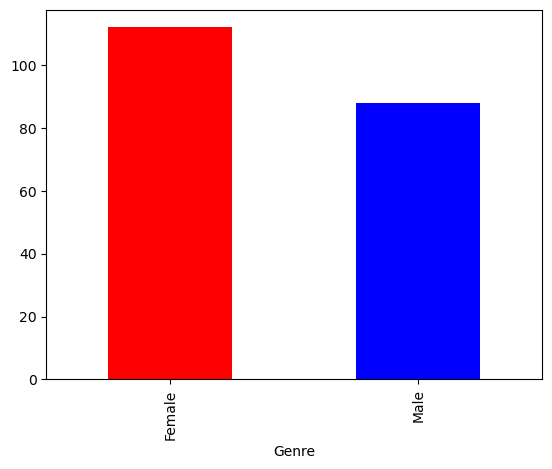

In [13]:
#4.ดูการแจกแจง โดยแสดงกราฟแท่งของลูกค้าแยกตามเพศ มีตัวอย่างคำสั่งในการ plot หลายรูปแบบ

data['Genre'].value_counts().plot(kind='bar',color=['r','b'])
plt.show()

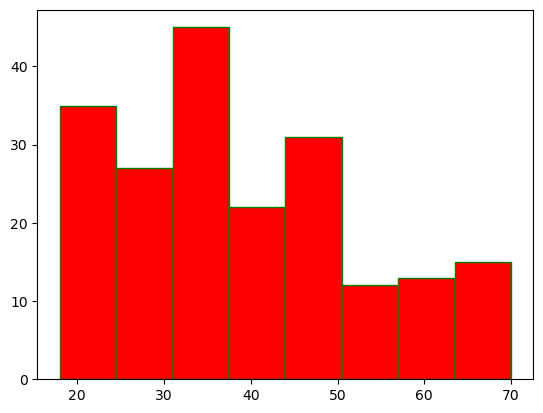

In [14]:
#5.สร้าง histogram ของอายุ แบ่งเป็น 8 bin
plt.hist(data['Age'],bins=8,color='red',edgecolor='green')
plt.show()

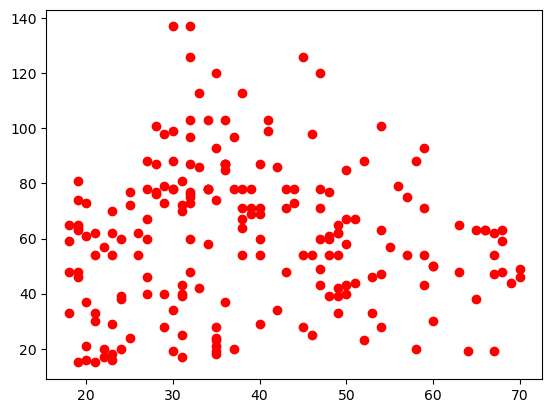

In [12]:
#6.ทำ scatter plot,pie ของข้อมูล Age, Income ทั้งแบบแยกและไม่แยกตามเพศ

plt.scatter(data['Age'], data['Annual Income (k$)'], color = "red")
plt.show()

176108.78
87121.56591478697
59492.737994932715
39529.88796736351
33453.06826765577
27105.885714285712
24937.494655967785
19153.02358606123
16948.79655847846


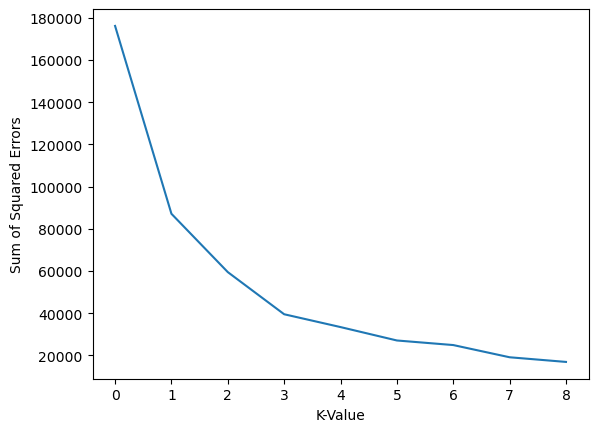

In [29]:
#7.นำ ข้อมูล Age, Income มาทำ clustering พิจารณาค่า K ที่ดีที่สุดเพื่อนำไปทำ K-Mean clustering
x1 = data[['Age', 'Annual Income (k$)']]
sse = []
k = range(1,10)
sum_squared_errors = []

for i in k:
  model = KMeans(n_clusters = i)
  model.fit_predict(x1)
  sum_squared_errors.append(model.inertia_)
  print(model.inertia_)  
plt.plot(sum_squared_errors)
plt.xlabel('K-Value')
plt.ylabel('Sum of Squared Errors')
plt.show()

In [30]:
#8.ได้ค่า k= ? ในการจัดกลุ่มโดยวิธี K-Means
k = 4

In [31]:
#9. แสดงเลขกลุ่มที่ข้อมูลแต่ละตัวอยู่กลุ่มไหน 
k_means = KMeans(n_clusters=4, init='random', max_iter=300)
k_means.fit(x1)
y = k_means.predict(x1)
cluster_label = k_means.labels_
print(cluster_label)

[2 2 2 2 2 2 2 2 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 2 2 2
 2 2 2 1 2 1 2 1 2 1 2 2 2 1 2 2 1 1 1 1 1 2 1 1 2 1 1 1 2 1 1 2 2 1 1 1 1
 1 0 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1
 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 3 0 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


[[ 31.95890411  72.95890411]
 [ 55.81481481  51.77777778]
 [ 30.34693878  29.26530612]
 [ 39.         106.5       ]]


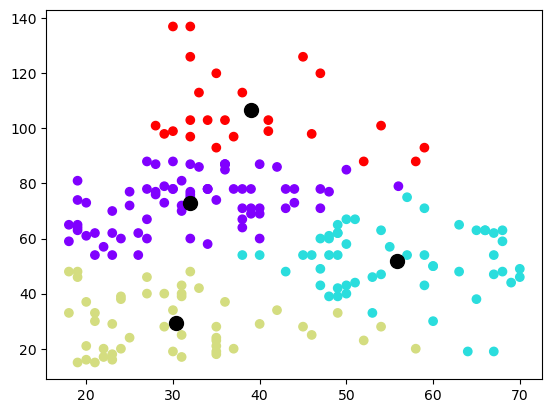

In [32]:
#10.ทำ scatter plot ที่แสดง centroid
plt.scatter(data['Age'], data['Annual Income (k$)'], c=cluster_label, marker="o",cmap='rainbow')
centers = k_means.cluster_centers_
print(centers) #พิมพ์จุดกลาง
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100)
plt.show()